## 사전학습 모델

- ResNet18 사용

### 1. 라이브러리 로드

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import requests
from PIL import Image
from io import BytesIO
import os
import random
import shutil

# 사전학습 모델 라이브러리 추가
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# pip install icrawler
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.12.0+cu130
True
13.0
NVIDIA GeForce RTX 5060


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### 2. ResNet18 사전학습 모델 로드
- 모델 다운로드 위치 변경가능

In [4]:
os.environ['TORCH_HOME'] = './cust_models'

In [5]:
# 사전학습 가중치 선택
weight = ResNet18_Weights.DEFAULT

# 사전학습 모델 불러오기
model = resnet18(weights=weight)

In [6]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### 3. 전처리 가져오기

- 직접 구성했던 transform을 자동 구성

In [7]:
preprocess = weight.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 4. 샘플이미지 예측

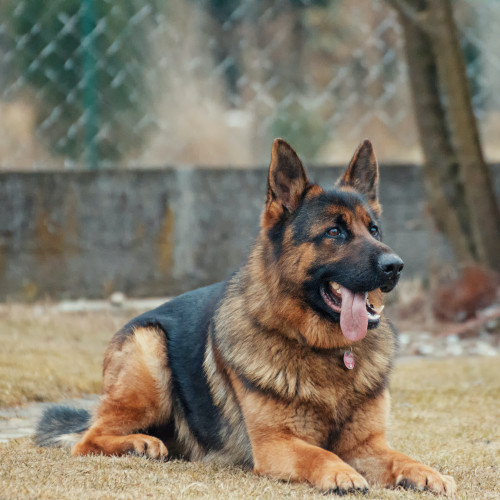

In [11]:
url = 'https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg'

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')  # L, 1, RGB, CMYK 
img

In [12]:
input_tensor = preprocess(img)
input_tensor.shape

torch.Size([3, 224, 224])

In [13]:
input_batch = input_tensor.unsqueeze(0) # 차원 추가
input_batch.shape

torch.Size([1, 3, 224, 224])

In [14]:
# 예측
model.eval() 
model = model.to(device)
input_batch = input_batch.to(device)

with torch.no_grad():
    output = model(input_batch)

output.shape  # torch.Size([1, 1000]) => 1000개 클래스 중 하나를 예측

torch.Size([1, 1000])

### 5. 예측결과 확인

In [15]:
prob = torch.softmax(output[0], dim=0)

top5_prob, top5_catid = torch.topk(prob, 5)

categories = weight.meta['categories']

for i in range(5):
    print(categories[top5_catid[i]], top5_prob[i].item())

German shepherd 0.9968082308769226
malinois 0.0015053615206852555
Norwegian elkhound 0.0006996517186053097
Leonberg 0.00041095231426879764
Tibetan mastiff 0.0001649117039050907


### 6. 이미지 다운로드

- dataset/train과 test 폴더 아래
    - dog
    - cat
    - horse

- icrawler.BingImageCrawler 사용 이미지 다운로드

In [26]:
raw_dir = 'raw'
dataset_dir = 'dataset/train'
testset_dir = 'dataset/test'

classes = {
    'dog photo': 'dog',
    'cat photo': 'cat',
    'bird photo': 'bird'
}

num_classes = 3
batch_size = 16
num_epoch = 5
lr = 0.001

In [ ]:
# 학습이미지 폴더
# 반복 다운로드 가능
for keyword, class_name in classes.items():
    save_dir = os.path.join(dataset_dir, class_name)
    # print(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    crawler = BingImageCrawler(
        storage={'root_dir': save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=150
    )

2026-05-21 12:28:58,840 - INFO - icrawler.crawler - start crawling...
2026-05-21 12:28:58,840 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 12:28:58,841 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 12:28:58,843 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 12:28:59,226 - INFO - parser - parsing result page https://www.bing.com/images/async?q=dog photo&first=0
2026-05-21 12:28:59,238 - INFO - downloader - skip downloading file 000001.jpg
2026-05-21 12:28:59,240 - INFO - downloader - skip downloading file 000002.jpg
2026-05-21 12:28:59,240 - INFO - downloader - skip downloading file 000003.jpg
2026-05-21 12:28:59,240 - INFO - downloader - skip downloading file 000004.jpg
2026-05-21 12:28:59,241 - INFO - downloader - skip downloading file 000005.jpg
2026-05-21 12:28:59,241 - INFO - downloader - skip downloading file 000006.jpg
2026-05-21 12:28:59,242 - INFO - downloader - skip downloading file 000007.jpg
2026-05-21 12:

In [65]:
# 테스트이미지 폴더
# 반복 다운로드 가능
for keyword, class_name in classes.items():
    save_dir = os.path.join(testset_dir, class_name)
    # print(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    # BingImageCrawler
    crawler = BaiduImageCrawler(
        storage={'root_dir': save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=150
    )

2026-05-21 15:32:55,789 - INFO - icrawler.crawler - start crawling...
2026-05-21 15:32:55,790 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 15:32:55,791 - INFO - feeder - thread feeder-001 exit
2026-05-21 15:32:55,793 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 15:32:55,794 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 15:32:57,559 - INFO - parser - parsing result page http://image.baidu.com/search/acjson?tn=resultjson_com&ipn=rj&word=dog photo&pn=0&rn=30
2026-05-21 15:32:58,270 - INFO - downloader - image #1	https://gimg2.baidu.com/image_search/src=http%3A%2F%2Fss2.meipian.me%2Fusers%2F50628749%2Fc5916810-a512-11ef-92fd-2d0d6eaec733.jpg%3FimageView2%2F2%2Fw%2F750%2Fh%2F1400%2Fq%2F80&refer=http%3A%2F%2Fss2.meipian.me&app=2002&size=f9999,10000&q=a80&n=0&g=0n&fmt=auto?sec=1781937176&t=beded29d17d8a5e5cbdf8b59b0aaa243
2026-05-21 15:32:59,252 - INFO - downloader - image #2	https://hellorfimg.zcool.cn/large/2547222029.j

### 7. 커스텀데이터셋용 FC 변경
- 1000개 클래스에서 3개로 변경

In [28]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [29]:
# 분류를 3가지만 할 예정
num_classes = 3

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)

model = model.to(device)
model.fc

Linear(in_features=512, out_features=3, bias=True)

### 8. 재학습용 설정
- fc층 파라미터 재학습설정
- 옵티마이저 설정

In [30]:
for param in model.parameters():
    param.requires_grad = False   # 학습시키지 말것

for param in model.fc.parameters():
    param.requires_grad = True   # 다시 학습

In [42]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

### 9. 데이터셋 불러오기
- dataset/train 폴더 내 데이터셋 로드

In [35]:
train_dataset = ImageFolder(
    root=dataset_dir,
    transform=preprocess
)
test_dataset = ImageFolder(
    root=testset_dir,
    transform=preprocess
)
print(train_dataset, test_dataset)

Dataset ImageFolder
    Number of datapoints: 75
    Root location: dataset/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           ) Dataset ImageFolder
    Number of datapoints: 66
    Root location: dataset/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )


In [36]:
train_dataset.classes, test_dataset.classes

(['bird', 'cat', 'dog'], ['bird', 'cat', 'dog'])

In [37]:
train_dataset.class_to_idx, test_dataset.class_to_idx

({'bird': 0, 'cat': 1, 'dog': 2}, {'bird': 0, 'cat': 1, 'dog': 2})

### 10. 데이터로더 변환

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True    
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f'train 데이터로더 개수 : {len(train_loader)}')  # ??
print(f'test 데이터로더 개수 : {len(test_loader)}')

train 데이터로더 개수 : 5
test 데이터로더 개수 : 5


### 11. 이미지 배치 확인

In [41]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


### 12. 학습 

In [43]:
model = model.to(device)

In [45]:
for epoch in range(num_epoch):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    avg_loss = train_loss / len(train_loader)
    accuracy = train_correct / train_total

    print(f'Epoch [{epoch+1:2d}/{num_epoch:2d}]')
    print(f'Train Loss : {train_loss:.4f}')
    print(f'Train Acc : {accuracy:.4f}')
    print(f'Avg Loss : {avg_loss:.4f}')

Epoch [ 1/ 5]
Train Loss : 0.9126
Train Acc : 1.0000
Avg Loss : 0.1825
Epoch [ 2/ 5]
Train Loss : 0.7114
Train Acc : 1.0000
Avg Loss : 0.1423
Epoch [ 3/ 5]
Train Loss : 0.6586
Train Acc : 1.0000
Avg Loss : 0.1317
Epoch [ 4/ 5]
Train Loss : 0.6044
Train Acc : 1.0000
Avg Loss : 0.1209
Epoch [ 5/ 5]
Train Loss : 0.6600
Train Acc : 0.9867
Avg Loss : 0.1320


### 13. 테스트 데이터셋 평가

In [47]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predict = torch.max(outputs, 1)

        test_correct += (predict == labels).sum().item()
        test_total += labels.size(0)

test_acc = test_correct / test_total
print(f'테스트 정확도 : {test_acc:.4f}')

테스트 정확도 : 1.0000


### 14. 웹크롤링으로 이미지 크롤링 다운로드

In [63]:
keywords = [
    'golden retriever dog',
    'labrador dog',
    'husky dog',
    'poodle dog',
    'bulldog dog',
    'puppy dog',
    'small dog',
    'big dog',
    'cute dog',
    'black dog',
    'white dog',
    'brown dog',
    'running dog',
    'dog face',
    'dog outdoors',
    'dog sitting',
    'dog playing',
    'pet dog',
    'domestic dog',
    'happy dog',
    'sleeping dog',
    'dog portrait',
    'street dog',
    'dog on grass',
    'family dog'
]

# 0, 'golden retriever dog'
# 1, 'labrador dog'
for idx, keyword in enumerate(keywords):

    temp_dir = f'dataset/test/dog/temp_{idx}'
    os.makedirs(temp_dir, exist_ok=True)

    ## BindImageCrawler 보다 BaiduImageCrawler 가 훨씬 강력
    crawler = BaiduImageCrawler(
        storage={'root_dir': temp_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=30
    )

print('Done!')

2026-05-21 15:12:34,437 - INFO - icrawler.crawler - start crawling...
2026-05-21 15:12:34,438 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 15:12:34,439 - INFO - feeder - thread feeder-001 exit
2026-05-21 15:12:34,441 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 15:12:34,443 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 15:12:37,270 - INFO - parser - parsing result page http://image.baidu.com/search/acjson?tn=resultjson_com&ipn=rj&word=golden retriever dog&pn=0&rn=30
2026-05-21 15:12:38,177 - INFO - downloader - image #1	https://bkimg.cdn.bcebos.com/pic/e4dde71190ef76c6a818bc979716fdfaae516747
2026-05-21 15:12:39,418 - INFO - downloader - image #2	https://hellorfimg.zcool.cn/large/1364400467.jpg
2026-05-21 15:12:41,223 - INFO - downloader - image #3	https://hellorfimg.zcool.cn/large/154876559.jpg
2026-05-21 15:12:41,735 - INFO - downloader - image #4	https://hellorfimg.zcool.cn/large/1956826150.jpg
2026-05-21 15:12:

Done!


### 15. 테스트 이미지 시각화

2026-05-21 15:05:25,773 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].


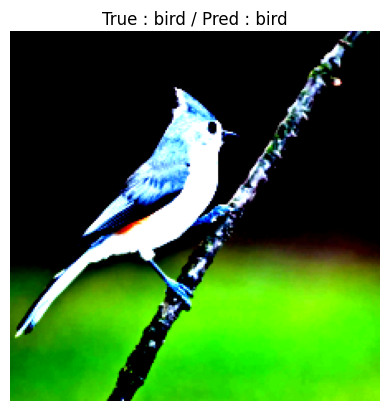

In [62]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

image = images[15]
label = labels[15]

input_batch = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_batch)
    pred = torch.argmax(output, 1).item()

image_np = image.permute(1, 2, 0).numpy()

plt.imshow(image_np)
plt.title(f'True : {test_dataset.classes[label]} / Pred : {test_dataset.classes[pred]}')
plt.axis('off')
plt.show()

### 16. 모델 저장

In [64]:
torch.save(
    model.state_dict(),
    'resnet18_bird_cat_dog.pth'
)